# DFT Relaxation Summary

This notebook summarizes the results of the VASP structural relaxation stored in the `relaxation/` folder.

It covers:

1. **Calculation setup** — parameters read from the `INCAR`/`KPOINTS`.
2. **Relaxed structure** — composition, lattice, and geometry from the `CONTCAR`.
3. **Ionic convergence** — total energy vs. ionic step from the `OSZICAR`.
4. **Band gap** — extracted from the `EIGENVAL` eigenvalues, including whether it is **direct or indirect**.
5. **Density of states (DOS)** — total DOS from the `DOSCAR` (element-projected DOS if available).

> **Note on the band gap / direct-vs-indirect test.** This is a self-consistent calculation on a
> Monkhorst–Pack k-mesh (11×11×11), *not* a band-structure calculation along high-symmetry lines.
> The VBM/CBM are therefore located among the k-points of the SCF mesh. This gives a reliable *value*
> for the gap and a good indication of direct vs. indirect character, but for a publication-quality
> band structure a dedicated non-self-consistent run along a k-path (e.g. Γ–M–K–Γ–A) is recommended.

In [1]:
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from ase.io import read

CALC_DIR = Path("relaxation")
assert CALC_DIR.is_dir(), f"Calculation directory not found: {CALC_DIR.resolve()}"

plt.rcParams.update(
    {
        "font.family": "serif",  # use serif/main font for text elements
        "text.usetex": True,  # use inline math for ticks
        "pgf.rcfonts": False,  # don't setup fonts from rc parameters
        "axes.labelsize": 14,  # axis labels
        "legend.fontsize": 12,  # legend
        "xtick.labelsize": 12,  # x tick labels
        "ytick.labelsize": 12,  # y tick labels
    }
)

## 1. Calculation setup

Key parameters from the `INCAR` and the k-point mesh from `KPOINTS`.

In [2]:
def parse_incar(path):
    params = {}
    for line in Path(path).read_text().splitlines():
        line = line.split("#")[0].split("!")[0].strip()
        if "=" in line:
            key, val = line.split("=", 1)
            params[key.strip().upper()] = val.strip()
    return params

incar = parse_incar(CALC_DIR / "INCAR")

print("INCAR parameters")
print("-" * 30)
for k, v in incar.items():
    print(f"  {k:8s} = {v}")

print("\nKPOINTS")
print("-" * 30)
print((CALC_DIR / "KPOINTS").read_text())

xc = {"PE": "PBE (GGA)", "PS": "PBEsol", "RP": "revPBE"}.get(incar.get("GGA", "").upper(), incar.get("GGA", "?"))
print(f"Exchange-correlation functional : {xc}")
print(f"Plane-wave cutoff (ENCUT)       : {incar.get('ENCUT', '?')} eV")
print(f"Relaxation (IBRION/ISIF)        : IBRION={incar.get('IBRION','?')}, ISIF={incar.get('ISIF','?')} "
      f"(ISIF=3 -> ions + cell shape + volume relaxed)")

INCAR parameters
------------------------------
  ENCUT    = 520.000000
  SIGMA    = 0.050000
  EDIFF    = 1.00e-06
  EDIFFG   = -1.00e-02
  GGA      = PE
  PREC     = Accurate
  IBRION   = 2
  ISIF     = 3
  ISMEAR   = 0
  KPAR     = 8
  NSW      = 100
  NCORE    = 8
  LCHARG   = .TRUE.
  LWAVE    = .TRUE.
  LREAL    = .FALSE.

KPOINTS
------------------------------
KPOINTS created by Atomic Simulation Environment
0
Gamma
9 9 2
0 0 0

Exchange-correlation functional : PBE (GGA)
Plane-wave cutoff (ENCUT)       : 520.000000 eV
Relaxation (IBRION/ISIF)        : IBRION=2, ISIF=3 (ISIF=3 -> ions + cell shape + volume relaxed)


## 2. Relaxed structure

The final relaxed geometry is stored in `CONTCAR`. We read it with ASE and report the composition, lattice parameters, and cell volume.

In [3]:
atoms = read(CALC_DIR / "CONTCAR")

cell = atoms.cell
a, b, c = cell.lengths()
alpha, beta, gamma = cell.angles()

from collections import Counter
comp = Counter(atoms.get_chemical_symbols())
formula = "".join(f"{el}{comp[el]}" for el in sorted(comp))

print(f"Chemical formula        : {atoms.get_chemical_formula()}  ({formula})")
print(f"Number of atoms         : {len(atoms)}")
print(f"Composition             : {dict(comp)}")
print()
print("Lattice parameters (relaxed, from CONTCAR)")
print("-" * 42)
print(f"  a = {a:8.4f} Å    alpha = {alpha:7.3f}°")
print(f"  b = {b:8.4f} Å    beta  = {beta:7.3f}°")
print(f"  c = {c:8.4f} Å    gamma = {gamma:7.3f}°")
print(f"  cell volume = {atoms.get_volume():.4f} Å³")
print()
print("This is a hexagonal cell (a=b, gamma=120°) with a long c axis — a layered structure.")

Chemical formula        : Cu3N6Ta3  (Cu3N6Ta3)
Number of atoms         : 12
Composition             : {'Ta': 3, 'Cu': 3, 'N': 6}

Lattice parameters (relaxed, from CONTCAR)
------------------------------------------
  a =   3.1511 Å    alpha =  90.000°
  b =   3.1511 Å    beta  =  90.000°
  c =  17.5726 Å    gamma = 120.000°
  cell volume = 151.1103 Å³

This is a hexagonal cell (a=b, gamma=120°) with a long c axis — a layered structure.


## 3. Ionic convergence

We parse the free energy `F=` of each completed ionic step from the `OSZICAR` to confirm the relaxation converged to a stable minimum.

Number of ionic steps   : 5
Final total energy      : -103.264480 eV
                        = -8.605373 eV/atom
ΔE last step            : -1.00e-05 eV


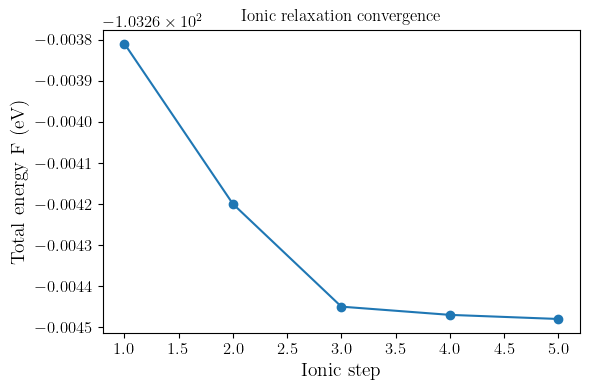

In [4]:
steps, energies = [], []
for line in (CALC_DIR / "OSZICAR").read_text().splitlines():
    m = re.search(r"^\s*(\d+)\s+F=\s*([-\d.E+]+)", line)
    if m:
        steps.append(int(m.group(1)))
        energies.append(float(m.group(2)))

energies = np.array(energies)
E_final = energies[-1]
print(f"Number of ionic steps   : {len(steps)}")
print(f"Final total energy      : {E_final:.6f} eV")
print(f"                        = {E_final/len(atoms):.6f} eV/atom")
if len(energies) > 1:
    print(f"ΔE last step            : {energies[-1]-energies[-2]:+.2e} eV")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(steps, energies, "o-", color="#1f77b4")
ax.set_xlabel("Ionic step")
ax.set_ylabel("Total energy F (eV)")
ax.set_title("Ionic relaxation convergence")
fig.tight_layout()
plt.show()

## 4. Band gap (direct vs. indirect)

We read all eigenvalues from `EIGENVAL`. For each k-point we find the valence-band maximum (VBM, highest occupied state) and conduction-band minimum (CBM, lowest unoccupied state). The band gap is `CBM − VBM` over the whole mesh; if the VBM and CBM occur at the **same** k-point the gap is **direct**, otherwise **indirect**.

In [5]:
def parse_eigenval(path):
    tokens = Path(path).read_text().split("\n")
    # Header: lines 0-5. Line index 5 holds: nelect nkpts nbands
    nelect, nkpts, nbands = (int(x) for x in tokens[5].split())
    kpoints = np.zeros((nkpts, 3))
    weights = np.zeros(nkpts)
    eigs = np.zeros((nkpts, nbands))
    occs = np.zeros((nkpts, nbands))
    i = 6
    for ik in range(nkpts):
        while tokens[i].strip() == "":  # skip blank separator line(s)
            i += 1
        kx, ky, kz, w = (float(x) for x in tokens[i].split())
        kpoints[ik] = (kx, ky, kz)
        weights[ik] = w
        i += 1
        for ib in range(nbands):
            parts = tokens[i].split()
            eigs[ik, ib] = float(parts[1])
            occs[ik, ib] = float(parts[2])
            i += 1
    return nelect, kpoints, weights, eigs, occs

nelect, kpoints, weights, eigs, occs = parse_eigenval(CALC_DIR / "EIGENVAL")
nkpts, nbands = eigs.shape
print(f"Electrons / k-points / bands : {nelect} / {nkpts} / {nbands}")

# Fermi energy from OUTCAR (for reference / DOS alignment)
efermi = None
for line in (CALC_DIR / "OUTCAR").read_text().splitlines():
    m = re.search(r"E-fermi\s*:\s*([-\d.]+)", line)
    if m:
        efermi = float(m.group(1))
print(f"Fermi energy (OUTCAR)        : {efermi} eV")

Electrons / k-points / bands : 78 / 24 / 72
Fermi energy (OUTCAR)        : 5.3997 eV


In [6]:
# Occupation threshold: a band is 'occupied' if occupancy > 0.5 (max is 2 for ISPIN=1 stored as 1.0 here).
OCC_TOL = 0.5
occupied = occs > OCC_TOL

is_metal = False
vbm = -np.inf; cbm = np.inf
ik_vbm = ik_cbm = -1

for ik in range(nkpts):
    occ_e = eigs[ik][occupied[ik]]
    unocc_e = eigs[ik][~occupied[ik]]
    if occ_e.size == 0 or unocc_e.size == 0:
        continue
    top = occ_e.max()          # highest occupied at this k
    bot = unocc_e.min()         # lowest unoccupied at this k
    if top > vbm:
        vbm, ik_vbm = top, ik
    if bot < cbm:
        cbm, ik_cbm = bot, ik

# Metal check: does any band cross the VBM/CBM window (i.e. gap <= 0)?
gap = cbm - vbm
if gap <= 0:
    is_metal = True

print("=" * 50)
if is_metal:
    print("RESULT: The system is METALLIC (no band gap).")
    print(f"  VBM ({vbm:.4f} eV) >= CBM ({cbm:.4f} eV) -> bands overlap.")
else:
    kind = "DIRECT" if ik_vbm == ik_cbm else "INDIRECT"
    print(f"RESULT: {kind} band gap = {gap:.4f} eV")
    print("-" * 50)
    print(f"  VBM = {vbm:.4f} eV  at k-point #{ik_vbm}: {kpoints[ik_vbm]}")
    print(f"  CBM = {cbm:.4f} eV  at k-point #{ik_cbm}: {kpoints[ik_cbm]}")
    if kind == "INDIRECT":
        # also report the smallest direct gap (min over k of CBM(k)-VBM(k))
        direct_gaps = []
        for ik in range(nkpts):
            oe = eigs[ik][occupied[ik]]; ue = eigs[ik][~occupied[ik]]
            if oe.size and ue.size:
                direct_gaps.append((ue.min() - oe.max(), ik))
        dg, ik_dg = min(direct_gaps)
        print(f"  Smallest DIRECT gap = {dg:.4f} eV at k-point #{ik_dg}: {kpoints[ik_dg]}")
print("=" * 50)
print("\n(Reminder: VBM/CBM taken over the SCF Monkhorst-Pack mesh, not a k-path.)")

RESULT: INDIRECT band gap = 0.5213 eV
--------------------------------------------------
  VBM = 5.0941 eV  at k-point #12: [1.276756e-15 1.276756e-15 5.000000e-01]
  CBM = 5.6154 eV  at k-point #4: [4.444444e-01 1.289160e-15 1.276756e-15]
  Smallest DIRECT gap = 0.9982 eV at k-point #4: [4.444444e-01 1.289160e-15 1.276756e-15]

(Reminder: VBM/CBM taken over the SCF Monkhorst-Pack mesh, not a k-path.)


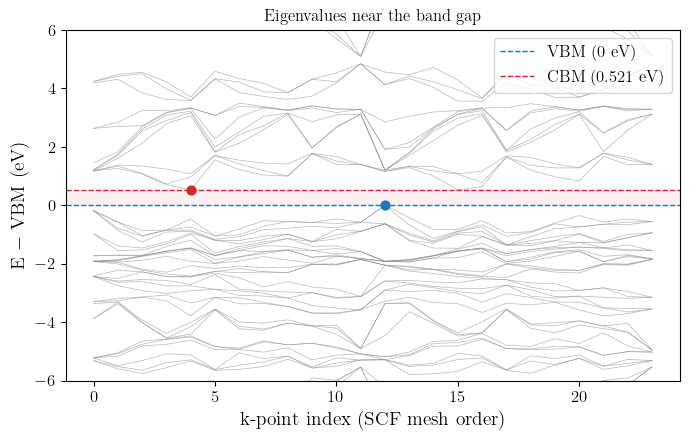

In [7]:
# Visualize the eigenvalues near the gap: highest few occupied and lowest few unoccupied
# bands across all k-points (states shifted so VBM = 0).
ref = 0.0 if is_metal else vbm
fig, ax = plt.subplots(figsize=(7, 4.5))
kidx = np.arange(nkpts)
for ib in range(nbands):
    band = eigs[:, ib] - ref
    if band.min() > 6 or band.max() < -6:
        continue  # only plot bands near the gap for clarity
    ax.plot(kidx, band, lw=0.5, color="#888888", alpha=0.6)
if not is_metal:
    ax.axhline(0, color="#1f77b4", ls="--", lw=1, label=f"VBM (0 eV)")
    ax.axhline(gap, color="#d62728", ls="--", lw=1, label=f"CBM ({gap:.3f} eV)")
    ax.axhspan(0, gap, color="#d62728", alpha=0.07)
    ax.scatter([ik_vbm], [0], color="#1f77b4", zorder=5, s=40)
    ax.scatter([ik_cbm], [gap], color="#d62728", zorder=5, s=40)
    ax.legend(loc="upper right")
ax.set_xlabel("k-point index (SCF mesh order)")
ax.set_ylabel("E − VBM (eV)")
ax.set_ylim(-6, 6)
ax.set_title("Eigenvalues near the band gap")
fig.tight_layout()
plt.show()

## 5. Density of states (DOS)

The total DOS is read from `DOSCAR`. Energies are shifted so that the Fermi level sits at 0 eV.

> **Note:** This `DOSCAR` contains only the **total** DOS — no site/orbital projections. That is because
> `LORBIT` was not set in the `INCAR`. To obtain an *element-projected* DOS, rerun a non-self-consistent
> step (`ICHARG=11`, reusing the `CHGCAR`) with `LORBIT = 11`; the parser below will then automatically
> pick up and plot the per-element contributions.

In [8]:
def parse_doscar(path):
    lines = Path(path).read_text().splitlines()
    natoms = int(lines[0].split()[0])
    # Line index 5 (6th line): emax emin nedos efermi weight
    header = lines[5].split()
    nedos = int(header[2])
    efermi = float(header[3])

    def block(start, n):
        return np.array([[float(x) for x in lines[start + j].split()] for j in range(n)])

    total = block(6, nedos)  # energy, dos(, integrated) ...
    energy = total[:, 0]
    tdos = total[:, 1]

    # Per-atom projected DOS (only present if LORBIT was set): each block is preceded by a
    # 1-line header identical in shape to line 5. Detect presence from the remaining line count.
    pdos = []
    pos = 6 + nedos
    have_pdos = len(lines) >= pos + natoms * (1 + nedos)
    if have_pdos:
        for _ in range(natoms):
            pos += 1  # skip the per-atom header line
            atomblock = block(pos, nedos)
            # columns after energy are the orbital-resolved DOS; sum them for a per-atom total
            pdos.append(atomblock[:, 1:].sum(axis=1))
            pos += nedos
    return energy, tdos, np.array(pdos), efermi, natoms

energy, tdos, pdos, efermi_dos, natoms = parse_doscar(CALC_DIR / "DOSCAR")
E = energy - efermi_dos  # shift so Fermi level = 0
has_pdos = pdos.size > 0
print(f"DOS grid points   : {len(energy)}")
print(f"Fermi energy      : {efermi_dos:.4f} eV (set to 0 in plots)")
print(f"Projected DOS     : {'yes, ' + str(pdos.shape[0]) + ' atoms' if has_pdos else 'not available (LORBIT not set)'}")

DOS grid points   : 301
Fermi energy      : 5.3997 eV (set to 0 in plots)
Projected DOS     : not available (LORBIT not set)


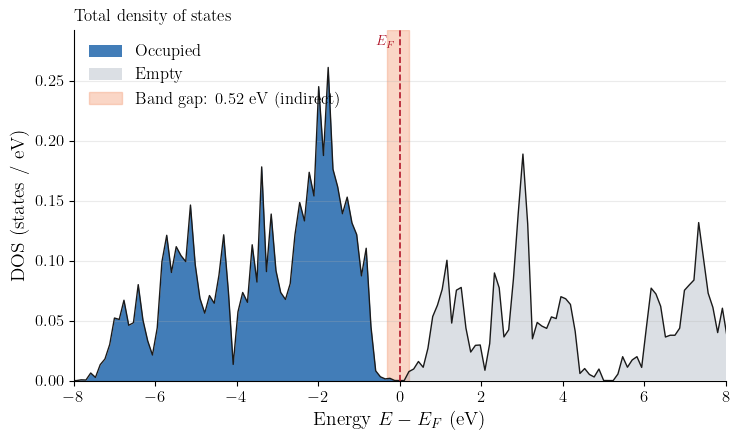

In [9]:
# Total DOS — occupied states filled, empty states outlined, band gap shaded.
OCC_COLOR = "#2166ac"    # occupied (below E_F): single saturated hue
EMPTY_COLOR = "#98a6b3"  # empty (above E_F): muted neutral
FERMI_COLOR = "#b2182b"  # Fermi level: reserved accent
GAP_COLOR = "#f4a582"    # band-gap band: warm tint, clearly visible

fig, ax = plt.subplots(figsize=(7.5, 4.5))

# Fixed, meaningful window and baseline pinned at 0 (DOS is non-negative).
XLO, XHI = -8, 8
win = (E > XLO) & (E < XHI)
ymax = tdos[win].max() * 1.12
ax.set_xlim(XLO, XHI)
ax.set_ylim(0, ymax)

occ = E <= 0  # occupied states sit below the Fermi level (E - E_F = 0)
ax.fill_between(E, tdos, where=occ, color=OCC_COLOR, alpha=0.85,
                interpolate=True, linewidth=0, label="Occupied")
ax.fill_between(E, tdos, where=~occ, color=EMPTY_COLOR, alpha=0.35,
                interpolate=True, linewidth=0, label="Empty")
ax.plot(E, tdos, color="#1a1a1a", lw=1.0)  # crisp outline over both fills

# Shade the band gap (only meaningful for a semiconductor/insulator); label it in the legend.
if not is_metal:
    kind = "direct" if ik_vbm == ik_cbm else "indirect"
    gap_lo, gap_hi = vbm - efermi_dos, cbm - efermi_dos
    ax.axvspan(gap_lo, gap_hi, color=GAP_COLOR, alpha=0.45, zorder=0,
               label=f"Band gap: {gap:.2f} eV ({kind})")

# Fermi level reference line.
ax.axvline(0, color=FERMI_COLOR, ls="--", lw=1.2)
ax.text(-0.15, ymax * 0.98, "$E_F$", color=FERMI_COLOR, fontsize=10, va="top", ha="right")

ax.set_xlabel("Energy  $E - E_F$  (eV)")
ax.set_ylabel("DOS (states / eV)")
ax.set_title("Total density of states", loc="left", fontsize=12, fontweight="bold")
ax.legend(loc="upper left", frameon=False)
ax.grid(axis="y", alpha=0.25)
ax.grid(axis="x", visible=False)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
fig.tight_layout()
plt.show()

In [10]:
# Element-projected DOS (only if the DOSCAR contains site projections).
symbols = atoms.get_chemical_symbols()
elements = sorted(set(symbols))
colors = {"Ta": "#1f77b4", "Cu": "#ff7f0e", "N": "#2ca02c"}

if has_pdos and pdos.shape[0] == len(symbols):
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for el in elements:
        idx = [i for i, s in enumerate(symbols) if s == el]
        el_dos = pdos[idx].sum(axis=0)
        c = colors.get(el, None)
        ax.plot(E, el_dos, lw=1.2, label=el, color=c)
        ax.fill_between(E, el_dos, alpha=0.15, color=c)
    ax.axvline(0, color="#d62728", ls="--", lw=1, label="Fermi level")
    ax.set_xlabel("Energy E − E$_F$ (eV)")
    ax.set_ylabel("DOS (states/eV)")
    ax.set_xlim(-10, 8)
    ax.set_title("Element-projected density of states")
    ax.legend()
    fig.tight_layout()
    plt.show()
else:
    print("Element-projected DOS is not available in this DOSCAR (LORBIT was not set).")
    print("See the note above for how to regenerate it. Showing the total DOS only (previous cell).")

Element-projected DOS is not available in this DOSCAR (LORBIT was not set).
See the note above for how to regenerate it. Showing the total DOS only (previous cell).


## 6. Summary

The cell below collects the headline numbers in one place.

In [11]:
print("DFT RELAXATION SUMMARY")
print("=" * 50)
print(f"Formula                 : {atoms.get_chemical_formula()}")
print(f"Functional / ENCUT      : {xc} / {incar.get('ENCUT','?')} eV")
print(f"Relaxed a = b           : {a:.4f} Å")
print(f"Relaxed c               : {c:.4f} Å")
print(f"Cell volume             : {atoms.get_volume():.3f} Å³")
print(f"Final total energy      : {E_final:.6f} eV ({E_final/len(atoms):.4f} eV/atom)")
print(f"Fermi energy            : {efermi:.4f} eV")
if is_metal:
    print(f"Electronic character    : metallic (no gap)")
else:
    kind = "direct" if ik_vbm == ik_cbm else "indirect"
    print(f"Band gap                : {gap:.4f} eV ({kind})")
print("=" * 50)
print("Note: PBE typically underestimates band gaps by ~30-50%.")

DFT RELAXATION SUMMARY
Formula                 : Cu3N6Ta3
Functional / ENCUT      : PBE (GGA) / 520.000000 eV
Relaxed a = b           : 3.1511 Å
Relaxed c               : 17.5726 Å
Cell volume             : 151.110 Å³
Final total energy      : -103.264480 eV (-8.6054 eV/atom)
Fermi energy            : 5.3997 eV
Band gap                : 0.5213 eV (indirect)
Note: PBE typically underestimates band gaps by ~30-50%.
